In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

In [68]:
df = pd.read_csv(r"C:\Users\HP\Documents\Learning Data Analytics\Python\Luke's Tutorial\Python_Data_Analytics_Course-main\data_jobs.csv")

In [69]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [70]:
def clean_list(skill_list):
    if pd.notna(skill_list):
       return ast.literal_eval(skill_list)

df['job_skills'] = df['job_skills'].apply(clean_list)
df['job_skills']

0                                                      None
1                [r, python, sql, nosql, power bi, tableau]
2         [python, sql, c#, azure, airflow, dax, docker,...
3         [python, c++, java, matlab, aws, tensorflow, k...
4         [bash, python, oracle, aws, ansible, puppet, j...
                                ...                        
785736    [bash, python, perl, linux, unix, kubernetes, ...
785737                               [sas, sas, sql, excel]
785738                                  [powerpoint, excel]
785739    [python, go, nosql, sql, mongo, shell, mysql, ...
785740                                          [aws, flow]
Name: job_skills, Length: 785741, dtype: object

In [35]:
df = df[df['job_title_short'] == 'Data Analyst'].copy()

In [4]:
df_explode = df.explode('job_skills')
#df_explode.groupby('job_skills')['salary_year_avg'].agg(['size','median'])
skill_stats = df_explode.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    medain_salary = ('salary_year_avg', 'median')
)

skill_stats = skill_stats.sort_values('skill_count', ascending = False).head(10)
skill_stats

NameError: name 'df' is not defined

In [3]:
skill_stats.plot(kind = 'scatter', x = 'skill_count', y = 'medain_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary vs Count of Job Posting for Top 10 Skills')
plt.tight_layout()

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i],skill_stats['medain_salary'].iloc[i], txt)
    
plt.show()

NameError: name 'skill_stats' is not defined

## Practice

In [92]:
df_exploaded = df.explode('job_skills')
df_exploaded = df_exploaded[df_exploaded['job_title_short'] == 'Data Analyst']

In [94]:
skill_stats = df_exploaded.groupby('job_skills').agg(
    skill_count = ('job_skills','count'),
    median_salary = ('salary_year_avg','median')
)

skill_stats = skill_stats.sort_values('skill_count', ascending = False).head(10)
skill_stats

,skill_count,median_salary
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


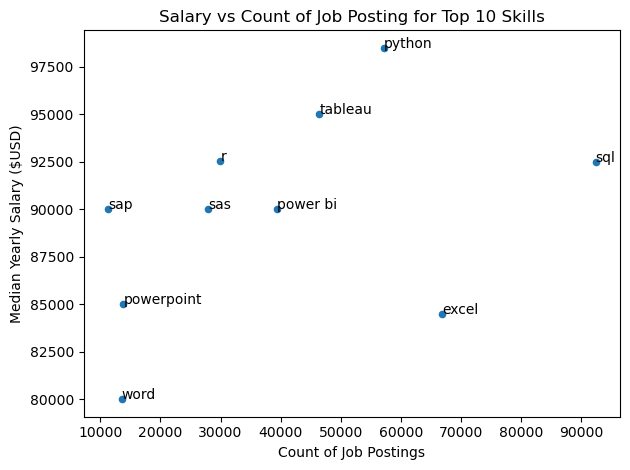

In [98]:
skill_stats.plot(kind = 'scatter', x = 'skill_count', y = 'median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary vs Count of Job Posting for Top 10 Skills')
plt.tight_layout()
for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i],skill_stats['median_salary'].iloc[i], txt)
plt.show()